In [1]:
! python -V

Python 3.14.2


In [ ]:
! python -m pip install numpy pandas matplotlib seaborn scikit-learn

In [4]:
import pandas

financiera = pandas.read_csv("financiera.csv") # DataFrame

financiera

,folio,amortizacionId,numero,concepto,plan,plazos,precio,interes,anticipo,subtotal,...,pagoMontoFaltante,pagoAnteriorId,pagoSiguienteId,vendedorRecibeFolio,sucursalRecibeFolio,vendedorOrigenFolio,sucursalOrigenFolio,liquidado,amortizacionAnteriorId,amortizacionSiguienteId
0,772,anticipo,0,Anticipo,nuevo,26,3999.0,190.0,799.0,6080.0,...,0.00,NaN,pago-1,33.0,6.0,12.0,14.0,0,NaN,pago-1
1,772,pago-1,1,Pago 1 de 26,nuevo,26,3999.0,190.0,799.0,6080.0,...,233.85,anticipo,pago-2,NaN,NaN,NaN,NaN,0,anticipo,pago-2
2,772,pago-2,2,Pago 2 de 26,nuevo,26,3999.0,190.0,799.0,6080.0,...,233.85,pago-1,pago-3,NaN,NaN,NaN,NaN,0,pago-1,pago-3
3,772,pago-3,3,Pago 3 de 26,nuevo,26,3999.0,190.0,799.0,6080.0,...,233.85,pago-2,pago-4,NaN,NaN,NaN,NaN,0,pago-2,pago-4
4,772,pago-4,4,Pago 4 de 26,nuevo,26,3999.0,190.0,799.0,6080.0,...,233.85,pago-3,pago-5,NaN,NaN,NaN,NaN,0,pago-3,pago-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13916,9,pago-14,14,Pago 14 de 18,nuevo,18,3999.0,170.0,799.0,5440.0,...,0.00,pago-13,pago-15,18.0,11.0,14.0,11.0,0,pago-13,pago-15
13917,9,pago-15,15,Pago 15 de 18,nuevo,18,3999.0,170.0,799.0,5440.0,...,0.00,pago-14,pago-16,14.0,11.0,14.0,11.0,0,pago-14,pago-16
13918,9,pago-16,16,Pago 16 de 18,nuevo,18,3999.0,170.0,799.0,5440.0,...,0.00,pago-15,pago-17,18.0,11.0,14.0,11.0,0,pago-15,pago-17
13919,9,pago-17,17,Pago 17 de 18,nuevo,18,3999.0,170.0,799.0,5440.0,...,0.00,pago-16,pago-18,18.0,11.0,14.0,11.0,0,pago-16,pago-18


In [9]:
financiera.info()

<class 'pandas.DataFrame'>
RangeIndex: 13921 entries, 0 to 13920
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   folio                           13921 non-null  int64  
 1   amortizacionId                  13921 non-null  str    
 2   numero                          13921 non-null  int64  
 3   concepto                        13921 non-null  str    
 4   plan                            13921 non-null  str    
 5   plazos                          13921 non-null  int64  
 6   precio                          13921 non-null  float64
 7   interes                         13921 non-null  float64
 8   anticipo                        13921 non-null  float64
 9   subtotal                        13921 non-null  float64
 10  semanal                         13921 non-null  float64
 11  total                           13921 non-null  float64
 12  saldoTotal                      13921 non-n

In [6]:
financiera[["folio", "numero", "pagoFechaEsperada", "pagoFechaRecibido", "pagoMontoEsperado", "pagoMontoRecibido"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 13921 entries, 0 to 13920
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   folio              13921 non-null  int64  
 1   numero             13921 non-null  int64  
 2   pagoFechaEsperada  13921 non-null  str    
 3   pagoFechaRecibido  7986 non-null   str    
 4   pagoMontoEsperado  13921 non-null  float64
 5   pagoMontoRecibido  13921 non-null  float64
dtypes: float64(2), int64(2), str(2)
memory usage: 652.7 KB


In [18]:
financiera["saldoEsperado"] = financiera["saldoActual"] * financiera["pagado"]
financiera["saldoPagado"] = financiera["totalPagado"] * financiera["pagado"]
financiera["pagoMontoFijado"] = financiera["pagoMontoEsperado"]
financiera["pagoMontoCorriente"] = financiera["pagoMontoFijado"] * financiera["pagado"]

financiera

,folio,amortizacionId,numero,concepto,plan,plazos,precio,interes,anticipo,subtotal,...,vendedorOrigenFolio,sucursalOrigenFolio,liquidado,amortizacionAnteriorId,amortizacionSiguienteId,saldoEsperado,saldoPagado,pagoMontoFijado,pagoMontoPendiente,pagoMontoCorriente
0,772,anticipo,0,Anticipo,nuevo,26,3999.0,190.0,799.0,6080.0,...,12.0,14.0,0,NaN,pago-1,6080.00,799.00,799.00,799.00,799.00
1,772,pago-1,1,Pago 1 de 26,nuevo,26,3999.0,190.0,799.0,6080.0,...,NaN,NaN,0,anticipo,pago-2,0.00,0.00,233.85,0.00,0.00
2,772,pago-2,2,Pago 2 de 26,nuevo,26,3999.0,190.0,799.0,6080.0,...,NaN,NaN,0,pago-1,pago-3,0.00,0.00,233.85,0.00,0.00
3,772,pago-3,3,Pago 3 de 26,nuevo,26,3999.0,190.0,799.0,6080.0,...,NaN,NaN,0,pago-2,pago-4,0.00,0.00,233.85,0.00,0.00
4,772,pago-4,4,Pago 4 de 26,nuevo,26,3999.0,190.0,799.0,6080.0,...,NaN,NaN,0,pago-3,pago-5,0.00,0.00,233.85,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13916,9,pago-14,14,Pago 14 de 18,nuevo,18,3999.0,170.0,799.0,5440.0,...,14.0,11.0,0,pago-13,pago-15,2417.80,3821.20,302.22,302.22,302.22
13917,9,pago-15,15,Pago 15 de 18,nuevo,18,3999.0,170.0,799.0,5440.0,...,14.0,11.0,0,pago-14,pago-16,2115.58,4123.42,302.22,302.22,302.22
13918,9,pago-16,16,Pago 16 de 18,nuevo,18,3999.0,170.0,799.0,5440.0,...,14.0,11.0,0,pago-15,pago-17,1813.36,4425.64,302.22,302.22,302.22
13919,9,pago-17,17,Pago 17 de 18,nuevo,18,3999.0,170.0,799.0,5440.0,...,14.0,11.0,0,pago-16,pago-18,1511.14,4727.86,302.22,302.22,302.22


In [20]:
factAvanceVentas = financiera.groupby("folio").agg({
    "plan": "first",
    "plazos": "first",
    "precio": "first",
    "anticipo": "first",
    "semanal": "first",
    "total": "first",
    "total": "first",
    "pagado": "sum",
    "pagoMontoFijado": "sum",
    "pagoMontoCorriente": "sum",
    "pagoMontoRecibido": "sum",
})

factAvanceVentas

,plan,plazos,precio,anticipo,semanal,total,pagado,pagoMontoFijado,pagoMontoCorriente,pagoMontoRecibido
folio,,,,,,,,,,
9,nuevo,18,3999.0,799.0,302.22,6239.00,19,6239.00,6239.00,5030.12
14,renovacion,35,10999.0,0.0,518.52,18148.35,11,18146.39,5185.20,3631.60
17,nuevo,35,10999.0,2499.0,510.00,20349.08,2,20349.08,3009.00,2499.00
18,renovacion,43,8799.0,0.0,347.87,14958.30,14,14958.30,4522.31,3130.83
23,nuevo,15,3999.0,799.0,320.00,5599.00,5,5599.00,2079.00,1759.00
...,...,...,...,...,...,...,...,...,...,...
764,renovacion,43,8999.0,0.0,209.28,8999.00,1,8999.00,0.00,0.00
766,renovacion,15,9499.0,0.0,949.90,14248.50,2,14248.50,949.90,949.90
767,renovacion,26,6699.0,749.5,366.12,10268.70,1,10268.70,749.50,749.50


In [21]:
factAvanceVentas.to_csv("financiera_avance_ventas.csv")

<Axes: xlabel='folio'>

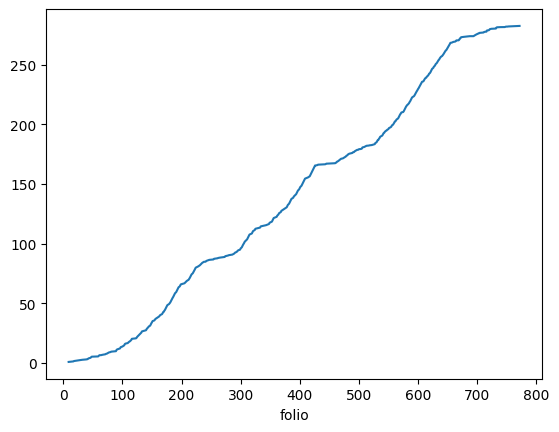

In [23]:
(factAvanceVentas["pagoMontoCorriente"] / factAvanceVentas["pagoMontoFijado"]).cumsum().plot()